In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/Users/linhhuynh/Desktop/DSC680/W 1 to 4/Natality, 2016-2024.csv")
df.head()

,Notes,Census Region of Residence,Census Region of Residence Code,State of Residence,State of Residence Code,Year,Year Code,Mother's Single Race 6,Mother's Single Race 6 Code,Mother's Education,Mother's Education Code,Births,Average Age of Mother (years),Average Birth Weight (grams),Average Pre-pregnancy BMI,Average Number of Prenatal Visits
0,NaN,Census Region 1: Northeast,CENS-R1,Connecticut,9.0,2020.0,2020.0,American Indian or Alaska Native,1002-5,8th grade or less,1,27.0,30.19,3212.04,27.45,10.22
1,NaN,Census Region 1: Northeast,CENS-R1,Connecticut,9.0,2020.0,2020.0,American Indian or Alaska Native,1002-5,9th through 12th grade with no diploma,2,48.0,27.15,3132.90,27.27,12.12
2,NaN,Census Region 1: Northeast,CENS-R1,Connecticut,9.0,2020.0,2020.0,American Indian or Alaska Native,1002-5,High school graduate or GED completed,3,83.0,27.16,3298.93,26.88,11.58
3,NaN,Census Region 1: Northeast,CENS-R1,Connecticut,9.0,2020.0,2020.0,American Indian or Alaska Native,1002-5,"Some college credit, but not a degree",4,48.0,28.75,3157.29,27.94,12.56
4,NaN,Census Region 1: Northeast,CENS-R1,Connecticut,9.0,2020.0,2020.0,American Indian or Alaska Native,1002-5,"Associate degree (AA, AS)",5,22.0,31.32,3196.91,27.32,13.18


In [3]:
import re

# Clean column names 
def clean_colname(c: str) -> str:
    c = c.strip().lower()
    c = c.replace("%", "pct")
    c = re.sub(r"[’']", "", c)          # remove apostrophes
    c = re.sub(r"[^a-z0-9]+", "_", c)   # non-alnum -> underscore
    c = re.sub(r"_+", "_", c).strip("_")
    return c

df = df.copy()
df.columns = [clean_colname(c) for c in df.columns]

print("\nCleaned columns:\n", df.columns.tolist())


Cleaned columns:
 ['notes', 'census_region_of_residence', 'census_region_of_residence_code', 'state_of_residence', 'state_of_residence_code', 'year', 'year_code', 'mothers_single_race_6', 'mothers_single_race_6_code', 'mothers_education', 'mothers_education_code', 'births', 'average_age_of_mother_years', 'average_birth_weight_grams', 'average_pre_pregnancy_bmi', 'average_number_of_prenatal_visits']


In [5]:
# Remove blank rows
key_cols = ["state_of_residence", "year", "births"]
for c in key_cols:
    if c not in df.columns:
        raise ValueError(f"Expected column missing: {c}")

df = df.dropna(subset=["state_of_residence", "births"], how="any").copy()

In [7]:
# Convert data type 

# Convert strings like "12.3" or "1,234" into numeric
def to_number(s):
    if pd.isna(s):
        return np.nan
    if isinstance(s, (int, float, np.number)):
        return s
    s = str(s).strip().replace(",", "")
    return pd.to_numeric(s, errors="coerce")

# Year & codes
for c in ["year", "state_of_residence_code", "year_code"]:
    if c in df.columns:
        df[c] = df[c].apply(to_number)

# Births numeric
df["births"] = df["births"].apply(to_number)

# Percent column (example: "1.23" or "1.23%")
if "pct_of_total_births" in df.columns:
    df["pct_of_total_births"] = (
        df["pct_of_total_births"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    df["pct_of_total_births"] = df["pct_of_total_births"].apply(to_number)

# Convert interval columns that are objects 
for c in [
    "average_interval_since_last_live_birth_months",
    "average_interval_since_last_other_pregnancy_outcome_months"
]:
    if c in df.columns:
        df[c] = df[c].apply(to_number)

# Make year integer 
if "year" in df.columns:
    df["year"] = df["year"].astype("Int64")

In [9]:
# Basic checks 
print("\nClean shape:", df.shape)
print("\nYears:", df["year"].dropna().unique())
print("\nMissing values (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))


Clean shape: (10867, 16)

Years: <IntegerArray>
[2020, 2021, 2022, 2023, 2024]
Length: 5, dtype: Int64

Missing values (top 15):
notes                              10867
census_region_of_residence             0
census_region_of_residence_code        0
state_of_residence                     0
state_of_residence_code                0
year                                   0
year_code                              0
mothers_single_race_6                  0
mothers_single_race_6_code             0
mothers_education                      0
mothers_education_code                 0
births                                 0
average_age_of_mother_years            0
average_birth_weight_grams             0
average_pre_pregnancy_bmi              0
dtype: int64


In [11]:
# Drop column "note"
df = df.drop(columns=["notes"], errors="ignore")
df.columns

Index(['census_region_of_residence', 'census_region_of_residence_code',
       'state_of_residence', 'state_of_residence_code', 'year', 'year_code',
       'mothers_single_race_6', 'mothers_single_race_6_code',
       'mothers_education', 'mothers_education_code', 'births',
       'average_age_of_mother_years', 'average_birth_weight_grams',
       'average_pre_pregnancy_bmi', 'average_number_of_prenatal_visits'],
      dtype='object')

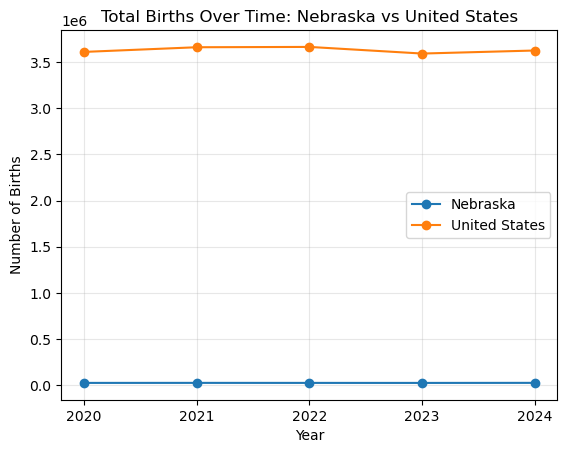

In [17]:
# VISUALS FOR 5-YEAR NATALITY DATA (2020–2024)

# Birth trends over time: Nebraska vs U.S.
plt.figure()
plt.plot(ne["year"], ne["births"], marker="o", label="Nebraska")
plt.plot(us["year"], us["births"], marker="o", label="United States")

years = sorted(df["year"].unique())
plt.xticks(years)

plt.title("Total Births Over Time: Nebraska vs United States")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This chart shows total births in Nebraska and the United States from 2020 to 2024. At the national level, births increase slightly from 2020 to 2022, drop in 2023, and then rise again in 2024. This pattern shows small changes over time rather than a steady decline.

Nebraska follows a very similar trend. Births rise slightly until 2022, decrease in 2023, and recover in 2024. Although Nebraska has far fewer births than the national total, the direction of change is the same.

Overall, the visual suggests that birth trends are relatively stable and that Nebraska’s pattern closely follows the national trend. This supports the use of short-term prediction models that focus on small year to year changes rather than long-term decline.

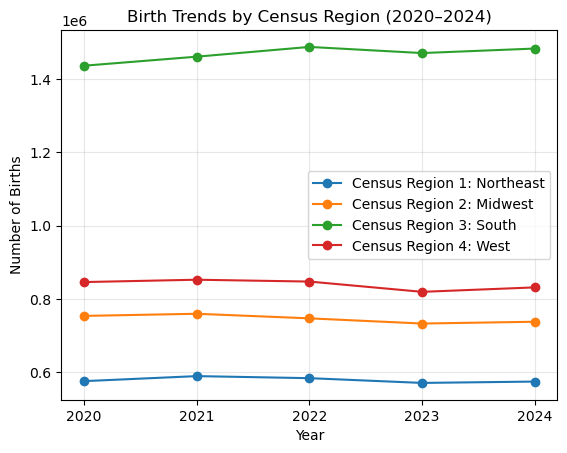

In [22]:
# Birth trends by Census region
plt.figure()
for region in region_year["census_region_of_residence"].unique():
    sub = region_year[region_year["census_region_of_residence"] == region]
    plt.plot(sub["year"], sub["births"], marker="o", label=region)

plt.xticks(years)
plt.title("Birth Trends by Census Region (2020–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This chart shows total births by U.S. Census region from 2020 to 2024. The South consistently has the highest number of births across all years, followed by the West, Midwest, and Northeast. This indicates that regional population size and demographic structure play an important role in birth volume.

Across regions, births generally increase slightly from 2020 to 2022, decline in 2023, and then show a small recovery in 2024. This shared pattern suggests that national factors, such as economic conditions or the effects of the COVID-19 period, influenced birth trends across all regions rather than changes limited to one area.

Overall, the visual shows that while birth levels differ by region, the direction of change over time is similar. This supports using region as an important predictor in modeling and suggests that future birth predictions should account for regional differences while recognizing common national trends.

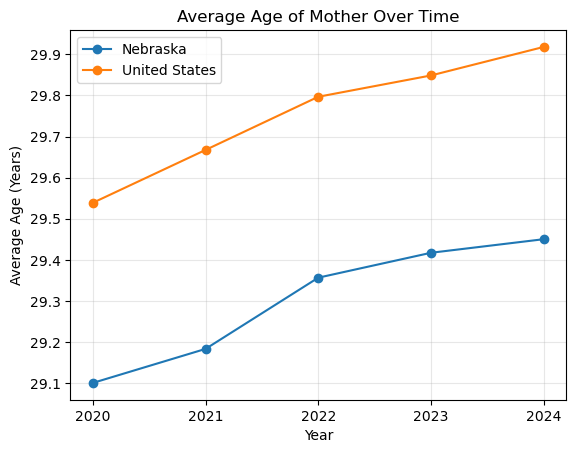

In [26]:
# Average age of mother over time
age_state_year = (
    df.groupby(["year", "state_of_residence"])["average_age_of_mother_years"]
      .mean()
      .reset_index()
)

ne_age = age_state_year[age_state_year["state_of_residence"] == "Nebraska"]
us_age = (
    df.groupby("year")["average_age_of_mother_years"]
      .mean()
      .reset_index()
)

plt.figure()
plt.plot(ne_age["year"], ne_age["average_age_of_mother_years"], marker="o", label="Nebraska")
plt.plot(us_age["year"], us_age["average_age_of_mother_years"], marker="o", label="United States")

plt.xticks(years)
plt.title("Average Age of Mother Over Time")
plt.xlabel("Year")
plt.ylabel("Average Age (Years)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This chart shows the average age of mothers in Nebraska and the United States from 2020 to 2024. In both cases, the average age increases steadily over the five-year period, indicating that women are having children later in life.

The national average age is consistently higher than Nebraska’s, but the gap between them remains small and stable. Nebraska follows the same upward pattern as the national trend, suggesting that state-level changes are influenced by broader national demographic shifts rather than unique local factors.

Overall, the increasing average age of mothers may help explain stable or slower growth in birth counts and is an important variable to include in predictive models for future maternity service demand.

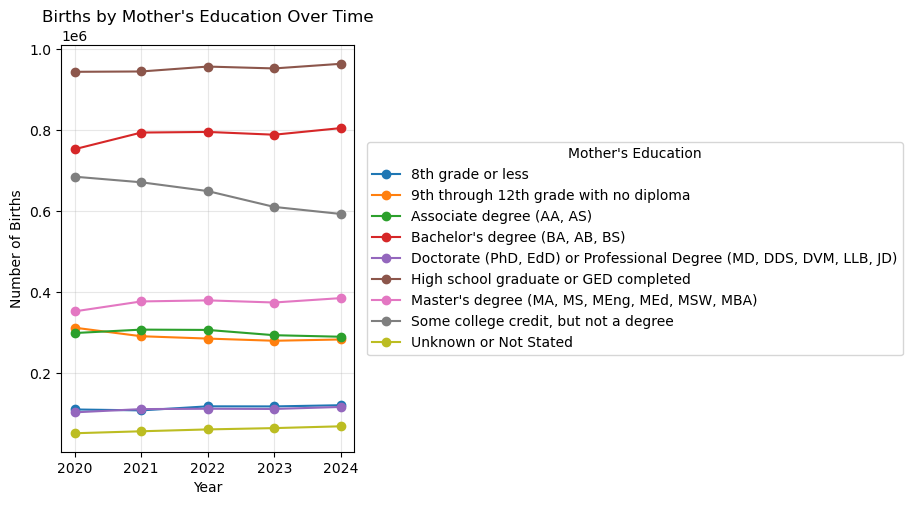

In [34]:
# Births by mother’s education over time
plt.figure(figsize=(12, 5))   

for edu in edu_year["mothers_education"].unique():
    sub = edu_year[edu_year["mothers_education"] == edu]
    plt.plot(sub["year"], sub["births"], marker="o", label=edu)

plt.xticks(years)
plt.title("Births by Mother's Education Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Births")


plt.legend(
    title="Mother's Education",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.grid(True, alpha=0.3)


plt.tight_layout(rect=[0, 0, 0.78, 1])

plt.show()

This chart shows how births are distributed by mother’s education level from 2020 to 2024. Mothers with a high school diploma or GED consistently account for the largest number of births across all years. Births to mothers with a bachelor’s degree are the second largest group and show a slight increase over time.

Births among mothers with some college but no degree decline steadily during this period, while births to mothers with a master’s degree increase slightly. Lower education categories, such as less than high school or unknown education, remain small and relatively stable.

Overall, the visual suggests a shift in births toward higher education levels over time. This pattern supports including mother’s education as an important predictor in birth modeling and may have implications for planning maternity services and support programs.

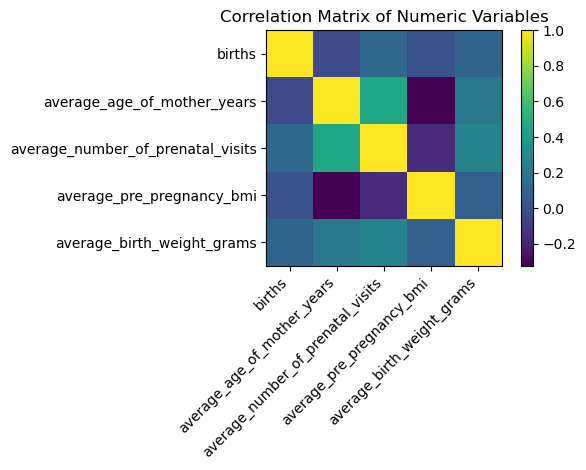

In [36]:
# Correlation heatmap (numeric predictors only)
num_cols = [
    "births",
    "average_age_of_mother_years",
    "average_number_of_prenatal_visits",
    "average_pre_pregnancy_bmi",
    "average_birth_weight_grams"
]

corr = df[num_cols].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

This correlation matrix shows the relationships between births and key maternal health variables. Overall, most correlations are weak to moderate, which suggests that no single variable strongly explains birth counts by itself.

Births have a small positive relationship with average prenatal visits and average birth weight, meaning areas with slightly higher prenatal care and birth weight tend to have slightly higher birth counts. The relationship between births and average age of mother is weak, indicating that age alone does not strongly drive total births.

Average age of mother shows a moderate positive correlation with the number of prenatal visits, suggesting that older mothers tend to receive more prenatal care. Average pre-pregnancy BMI has weak or negative relationships with other variables, indicating it captures a different aspect of maternal health.

Overall, the matrix suggests that these variables provide complementary information rather than duplicating each other. This supports keeping them as predictors in advanced models, as multicollinearity does not appear to be a major concern.

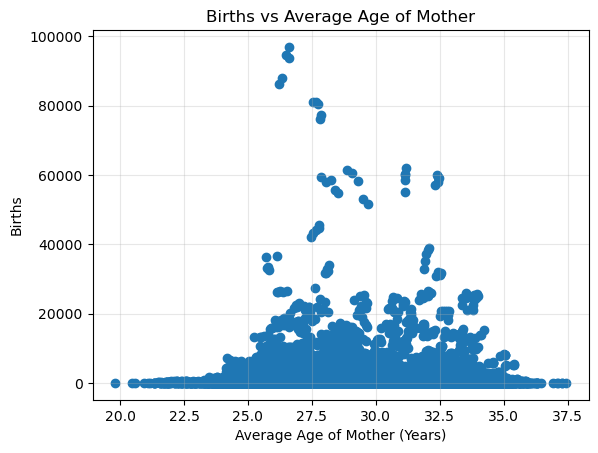

In [38]:
# Births vs maternal age (relationship check)
plt.figure()
plt.scatter(df["average_age_of_mother_years"], df["births"])
plt.title("Births vs Average Age of Mother")
plt.xlabel("Average Age of Mother (Years)")
plt.ylabel("Births")
plt.grid(True, alpha=0.3)
plt.show()

This scatter plot shows the relationship between total births and the average age of mothers. The points are widely spread, which indicates that there is no strong linear relationship between average maternal age and the number of births.

Most high birth counts occur when the average age of mothers is between the late 20s and early 30s, which is the typical childbearing age range. However, similar age ranges can have very different birth counts, suggesting that maternal age alone does not determine how many births occur.

Overall, this visual shows that average age of mother is an important contextual factor but cannot explain birth volume by itself. This supports using maternal age together with other variables, such as education, prenatal care, and geography, in predictive models rather than relying on a single predictor.

In [45]:
# MODELING

# Prepare modeling dataset
import pandas as pd
import numpy as np

# Copy to avoid modifying original df
df_model = df.copy()

# Drop ID/code columns
df_model = df_model.drop(columns=[
    "census_region_of_residence_code",
    "state_of_residence_code",
    "year_code",
    "mothers_single_race_6_code",
    "mothers_education_code"
], errors="ignore")

# Drop rows with missing target
df_model = df_model.dropna(subset=["births"])

print(df_model.shape)

(10867, 10)


In [47]:
# Train / test split by year
train = df_model[df_model["year"].between(2020, 2023)]
test  = df_model[df_model["year"] == 2024]

X_train = train.drop(columns=["births"])
y_train = train["births"]

X_test = test.drop(columns=["births"])
y_test = test["births"]

In [49]:
# Baseline model: Linear Regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

cat_cols = [
    "state_of_residence",
    "census_region_of_residence",
    "mothers_single_race_6",
    "mothers_education"
]

num_cols = [
    "year",
    "average_age_of_mother_years",
    "average_birth_weight_grams",
    "average_pre_pregnancy_bmi",
    "average_number_of_prenatal_visits"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

lin_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)

lin_pred = lin_model.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = mean_squared_error(y_test, lin_pred, squared=False)

print("Linear Regression MAE:", round(lin_mae, 2))
print("Linear Regression RMSE:", round(lin_rmse, 2))

Linear Regression MAE: 2036.27
Linear Regression RMSE: 4042.93


In [51]:
# Advanced model: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))

Random Forest MAE: 266.56
Random Forest RMSE: 944.27


In [53]:
# Compare models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lin_mae, rf_mae],
    "RMSE": [lin_rmse, rf_rmse]
})

comparison

,Model,MAE,RMSE
0,Linear Regression,2036.270966,4042.930598
1,Random Forest,266.556824,944.265269


In [55]:
# Predict 2025
# Create 2025 scenario using 2024 structure
X_2025 = X_test.copy()
X_2025["year"] = 2025

pred_2025 = rf_model.predict(X_2025)

print("Predicted total births in 2025:",
      round(pred_2025.sum()))

Predicted total births in 2025: 3603362
